In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


Matplotlib is building the font cache; this may take a moment.


In [3]:
training_df=pd.read_csv("training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,...,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.460000,95.428820,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.760000,13.110001,14.010000,21.910000,0.275,0.318,0.195,0.026,1
1,10.453500,95.428590,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.753500,13.103500,14.003500,21.903500,0.275,0.318,0.195,0.026,1
2,10.414500,95.427210,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.714500,13.064501,13.964500,21.864500,0.275,0.318,0.195,0.026,1
3,9.223500,99.663920,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.423500,12.823500,13.723500,21.923500,0.273,0.324,0.201,0.020,1
4,9.243000,99.663990,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.443000,12.842999,13.743000,21.942999,0.273,0.324,0.201,0.020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113891,28.476500,26.921050,7.6265,26.616827,0.0,0.0,0.0,0.0,1.0,1015.9,...,38.160000,41.726498,30.776499,26.726500,18.426498,0.042,0.134,0.192,0.235,0
113892,25.435000,36.749325,9.5850,24.854360,0.0,0.0,0.0,0.0,0.0,1009.1,...,17.640000,32.185000,28.734999,23.435000,17.535000,0.135,0.170,0.229,0.293,0
113893,13.914001,82.397710,10.9640,13.423975,0.0,0.0,0.0,0.0,3.0,1012.1,...,18.720000,14.164001,13.364000,12.314000,12.314000,0.231,0.314,0.330,0.342,0
113894,7.604000,52.525845,-1.4960,4.411881,0.0,0.0,0.0,0.0,0.0,1017.0,...,18.720000,10.654000,14.604001,13.604000,7.954000,0.270,0.296,0.347,0.392,0


In [4]:
# Assume the last column is the label
labels = training_df.iloc[:, -1]  # Store labels separately for comparison
X = training_df.iloc[:, :-1]  # Remove labels


In [5]:
# Normalize the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
# # Apply PCA to reduce to 3D space
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
explained_variance_pca = sum(pca.explained_variance_ratio_) * 100
print(f"Explained Variance (3D): {explained_variance_pca:.2f}%")

# KMeans Clustering with Silhouette Score to find optimal k
silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, cluster_labels)
    silhouette_scores.append(score)


Explained Variance (3D): 47.44%


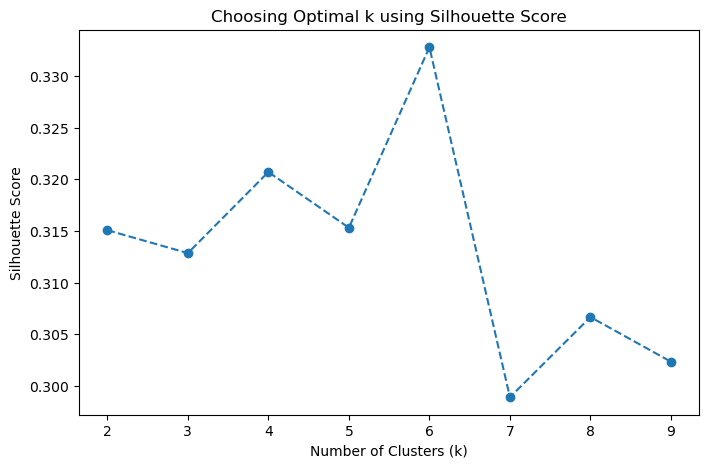

In [7]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Choosing Optimal k using Silhouette Score')
plt.show()


In [8]:
# Choose three optimal k values
optimal_ks = sorted(zip(k_values, silhouette_scores), key=lambda x: -x[1])[:3]


In [12]:
from mpl_toolkits.mplot3d import Axes3D


Silhouette Score for k=6: 0.3328


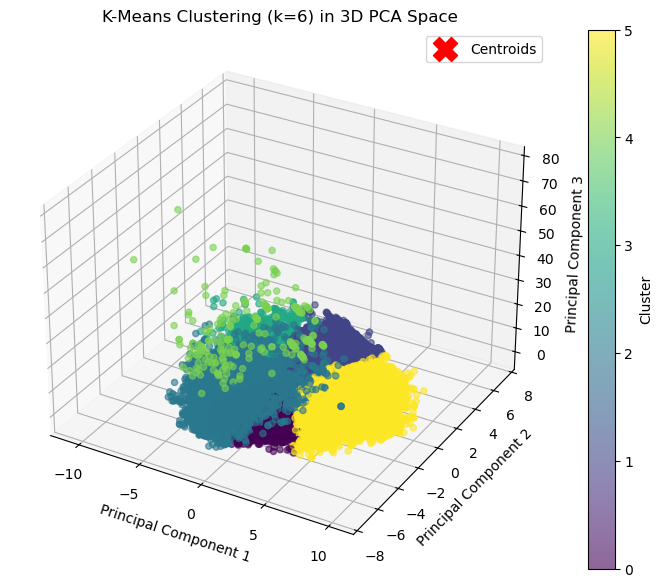

Silhouette Score for k=4: 0.3207


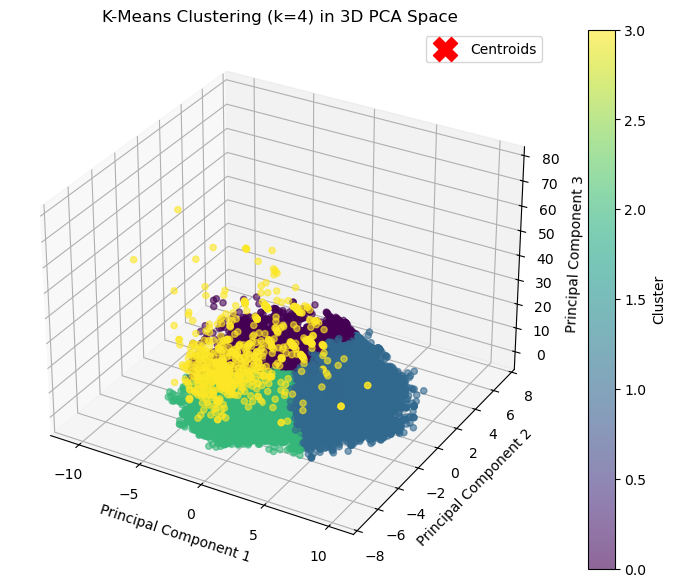

Silhouette Score for k=5: 0.3153


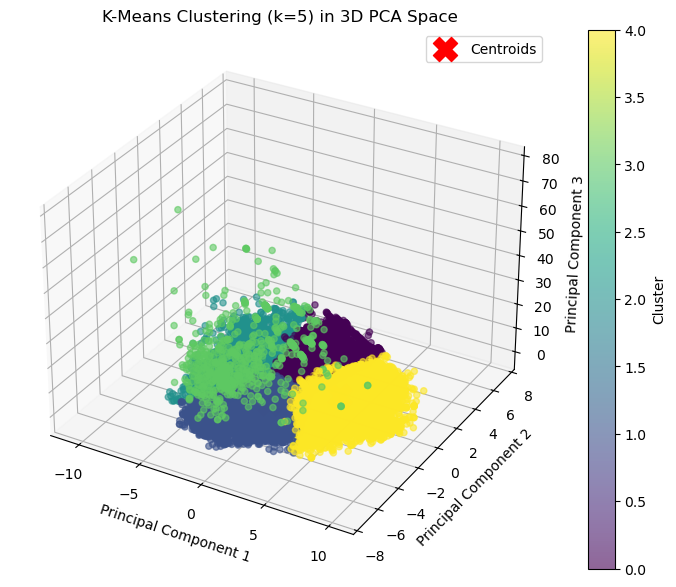

In [13]:
# Visualize KMeans for the top three k values in 3D
for k, _ in optimal_ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)

    # Compute silhouette score
    score = silhouette_score(X_pca, clusters)
    print(f"Silhouette Score for k={k}: {score:.4f}")

    # Create a 3D scatter plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap='viridis', alpha=0.6)

    # Plot cluster centroids in 3D
    ax.scatter(kmeans.cluster_centers_[:, 0], 
               kmeans.cluster_centers_[:, 1], 
               kmeans.cluster_centers_[:, 2], 
               s=300, c='red', marker='X', label="Centroids")

    # Set labels and title
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_zlabel("Principal Component 3")
    ax.set_title(f"K-Means Clustering (k={k}) in 3D PCA Space")
    
    # Add color legend
    plt.colorbar(sc, label="Cluster")
    plt.legend()
    plt.show()


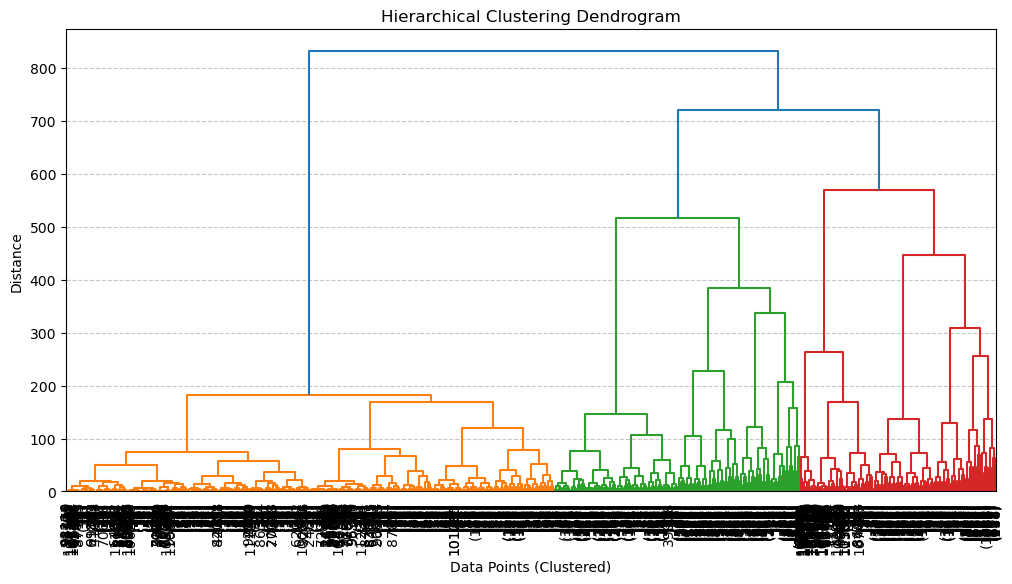

In [10]:
# Step 1: Compute linkage matrix (Ward's method)
linkage_matrix = linkage(X_pca, method='ward')

# Step 2: Plot the Dendrogram (Improved)
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="level",  # Show only the last few levels
    p=10,  # Limit number of merged clusters displayed
    color_threshold=0.7 * max(linkage_matrix[:, 2]),  # Auto color clusters
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points (Clustered)")
plt.ylabel("Distance")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()


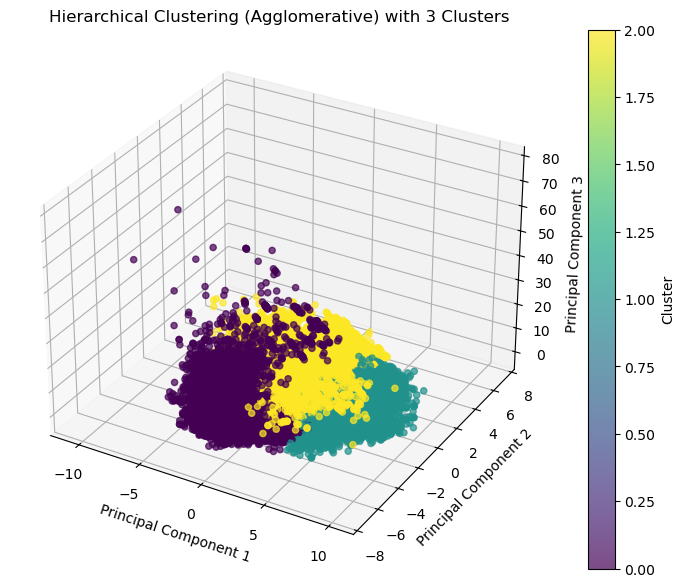

In [14]:
# Step 1: Apply Agglomerative Clustering
n_clusters = 3  # Adjusted based on dendrogram analysis
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = agg_clustering.fit_predict(X_pca)

# Step 2: Create a 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of clustered data
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)

# Labels and title
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title(f"Hierarchical Clustering (Agglomerative) with {n_clusters} Clusters")

# Add color legend
plt.colorbar(sc, label="Cluster")
plt.show()


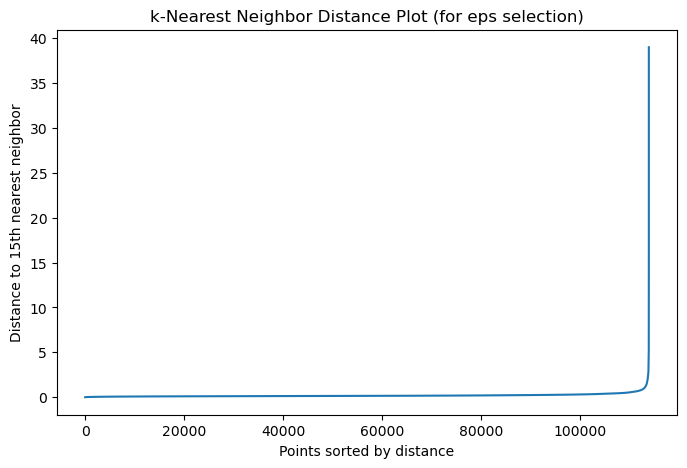

Estimated eps: 0.753


In [15]:
# Set min_samples based on dataset size
min_samples = 15  # Adjust between 15-20 for large datasets

# Compute nearest neighbors
nearest_neighbors = NearestNeighbors(n_neighbors=min_samples)
nearest_neighbors.fit(X_pca)
distances, _ = nearest_neighbors.kneighbors(X_pca)

# Sort distances to find the elbow
sorted_distances = np.sort(distances[:, -1])

# Plot k-distance graph
plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("k-Nearest Neighbor Distance Plot (for eps selection)")
plt.show()

# Choose an approximate `eps` from the elbow point in the plot
estimated_eps = sorted_distances[int(0.98 * len(sorted_distances))]  # Use 98th percentile
estimated_eps *= 1.1  # Slightly increase eps for more stable clusters
print(f"Estimated eps: {estimated_eps:.3f}")


In [16]:
from sklearn.cluster import DBSCAN

# Use the estimated `eps` from the plot
dbscan = DBSCAN(eps=estimated_eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_pca)

# Count clusters and noise points
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Excluding noise
num_noise = list(labels).count(-1)

print(f"DBSCAN found {num_clusters} clusters + {num_noise} noise points.")


DBSCAN found 10 clusters + 1085 noise points.


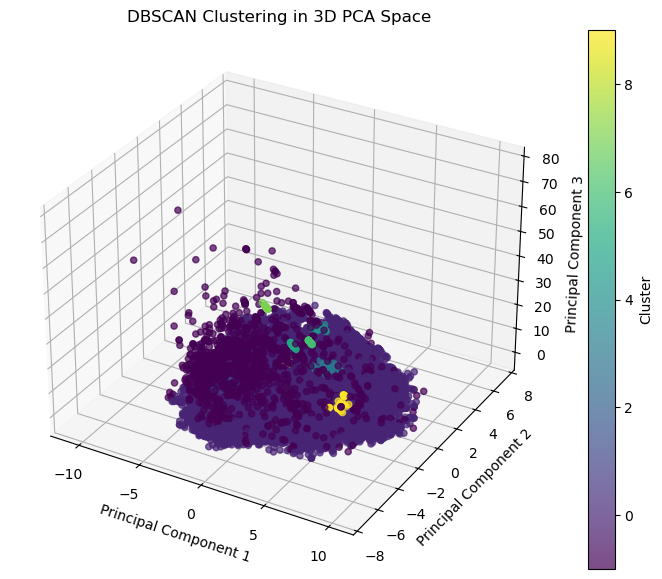

In [17]:
# Create a 3D Scatter Plot for DBSCAN
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of clustered data
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='viridis', alpha=0.7)

# Labels and title
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("DBSCAN Clustering in 3D PCA Space")

# Add color legend
plt.colorbar(sc, label="Cluster")
plt.show()
